# Activation Patching: Finding Causal Circuits

## Introduction and Setup

#### Introduction

Mechanistic interpretability (MI) is a subfield of AI research focused on reverse-engineering the human-understandable algorithms at play in neural Language Model (LM) computations.
Activation patching is a technique that lets us trace the LM components involved in specific behaviors.

The goal of this notebook is to explore activation patching through the lens of the similarity task: where we want the LM to discern which entity in a list has an attribute in common with a subject entity.
As we work on this task, we will also explore the theory behind activation patching, why certain decisions are made, and how activation patching helps us answer MI research questions.

#### Learning Objectives

1. Understand the core concepts behind activation patching.
2. Implement patching at different levels of granularity: residual stream, MLPs, and attention heads.
3. Apply advanced techniques like windowed and batch patching.
4. Interpret the results to form a hypothesis about the model's internal algorithm.

### Installs & Imports

In [46]:
%pip install -q torch nnsight

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [47]:
import torch
from nnsight import LanguageModel

### Model Setup

In [48]:
model_name = "meta-llama/Llama-3.3-70B-Instruct"

model = LanguageModel(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

In [49]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 8192)
    (layers): ModuleList(
      (0-79): 80 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=8192, out_features=8192, bias=False)
          (k_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (v_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (o_proj): Linear(in_features=8192, out_features=8192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (up_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (down_proj): Linear(in_features=28672, out_features=8192, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((8192,), eps=1e-05)
    (rotary_

Here we can see that Llama 70B is composed of 80 layers, each of which includes an attention layer, and an MLP layer. Each layer connects to the next through via addition to a skip-connection called the **residual stream**. We can get a sense for the relation between the residual stream, the attention layers, and the mlp layers in the diagram below:

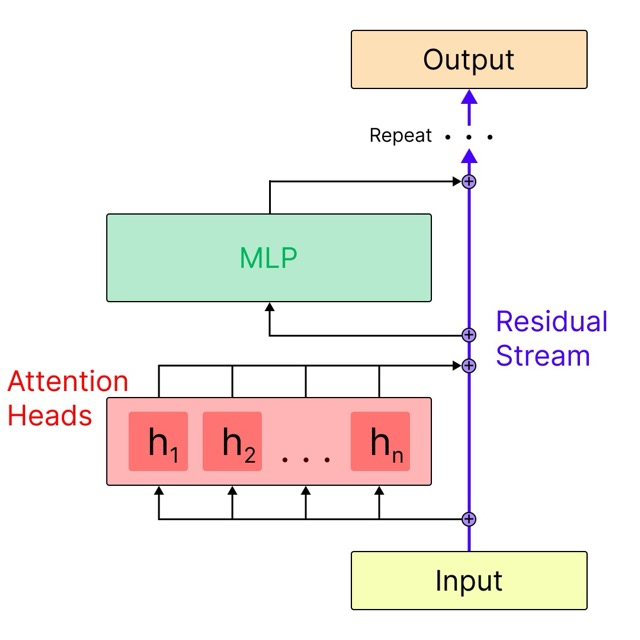

## The Selection Task & Core Concepts

### Defining the Experimental Setup

The similarity task asks the question: How does the model make a connection between two entities that share a common attribute?
For example, when asked "Which of the following entities has a profession in common with Will Smith? Keanu Reeves, Bill Clinton, Michael Jordan." the model should respond with "Keanu Reeves" since Will Smith and Keanu Reeves are both actors.

Activation patching can help us understand the LM components involved in making this connection.
We can think of a language model as being composed of a number of different structures.
Observing the architecture of the model reveals some of these components:

### Prompt Setup

Now, our goal is to track which parts of the model are most necessary for making the correct prediction of "Keanu Reeves" in this task.
To do this, we'll first need to define two prompts: one which we'll call the **clean prompt** and another we'll call the **corrupt prompt**.

In [ ]:
PROMPT_TEMPLATE = "Q: Which of the following entities has a profession in common with {}? {}.\nA:"
PROMPT_TEMPLATE = "Q: Which of the following entities has a profession in common with {}? {}.\nA:"

clean_subj = "Isaac Newton"
corrupt_subj = "Taylor Swift"

entity_list = ["Brad Pitt", "Albert Einstein", "Michael Jackson"]

clean_prompt = PROMPT_TEMPLATE.format(clean_subj, (", ").join(entity_list))
print("Clean Prompt:", clean_prompt, "\n")

corrupt_prompt = PROMPT_TEMPLATE.format(corrupt_subj, (", ").join(entity_list))
print("Corrupt Prompt:", corrupt_prompt)

Clean Prompt: Q: Which of the following entities has a profession in common with Will Smith? Keanu Reeves, Marie Curie, Frank Sinatra.
A: 

Corrupt Prompt: Q: Which of the following entities has a profession in common with Taylor Swift? Keanu Reeves, Marie Curie, Frank Sinatra.
A:


Having the corrupt prompt gives us a version where the correct answer changes. In this case we would expect the model to responde with "Frank Sinatra".
Now we'll be able to use activation patching to see which parts of the model are most important for changing the response from Frank Sinatra back to Keanu Reeves when we patch in the clean version where the only difference is replacing "Taylor Swift" with "Will Smith".

Let's make sure that our two subjects are the same token length so we don't have to do any position manipulation.

In [ ]:
print(model.tokenizer.encode(" Taylor Swift", add_special_tokens=False))
print(model.tokenizer.encode(" Will Smith", add_special_tokens=False))

[68236, 24594]
[10149, 9259]


### Save Clean & Corrupt Target Tokens

Since " Keanu" gets split into " K" and "eanu", if the model predicts " K" as the next token, we consider that a correct prediction for " Keanu".

In [51]:
keanu_token_id = model.tokenizer.encode(" K", add_special_tokens=False)
frank_token_id = model.tokenizer.encode(" Frank", add_special_tokens=False)

## Activation Patching

### Clean Run

Run the model on the clean input.
Cache activations of a set of given model components.

In [52]:
from tqdm import trange

clean_activations = []
with model.trace(clean_prompt):
    for l in trange(model.config.num_hidden_layers):
        residual_output = model.model.layers[l].output[0].save()
        clean_activations.append(residual_output)
    clean_keanu_logits = model.output.logits[0][-1, keanu_token_id].item().save()

print(f"{clean_keanu_logits=}")
print(f"{len(clean_activations)=}")

100%|██████████| 80/80 [00:00<00:00, 2714.32it/s]


Loading checkpoint shards:   0%|          | 0/30 [00:00<?, ?it/s]

clean_keanu_logits=19.703125
len(clean_activations)=80


### Corrupt Run

Run the model on the corrupt prompt and record outputs

In [54]:
with model.trace(corrupt_prompt):
    logits = model.output.logits.save()
    corrupt_keanu_logits = model.output.logits[0][-1, keanu_token_id].item().save()
corrupt_prediction = logits.argmax(dim=-1)[:, -1]
corrupt_token_prediction = model.tokenizer.decode(corrupt_prediction)

print(f"{corrupt_token_prediction=}")
print(f"{corrupt_keanu_logits=}")

corrupt_token_prediction=' Frank'
corrupt_keanu_logits=18.6875


### Baseline Logit Difference

This gives us a score of the difference between the models confidence in predicting " K" (the token corresponding to answering "Keanu") when we run the clean prompt versus when we run the corrupt prompt.

Note that there are only three possible options, so it is reasonable for this score to remain low even though Keanu would be an incorrect answer in the corrupt prompt.

In [55]:
print(f"Baseline logit difference (clean - corrupt): {clean_keanu_logits - corrupt_keanu_logits}")

Baseline logit difference (clean - corrupt): 1.015625


### Storing Token IDs

The clean input ids will be used for looping through token-by-token.
And both will be used later for decoding back into the tokens for the activation plots.

In [56]:
clean_input_ids = model.tokenizer.encode(clean_prompt)
corrupt_input_ids = model.tokenizer.encode(corrupt_prompt)

### Patched Run

Run the model on the corrupt input with residual stream activations restored from the clean run.

In [57]:
patched_activations = []

# Loop through the model layers
for l in trange(model.config.num_hidden_layers):

    patch_at_layer = []

    # For each token position
    for t in range(len(clean_input_ids)):

        # We run the model on the corrupt prompt
        with model.trace(corrupt_prompt):

            # Replace the residual stream output with the clean_activations at that token
            model.model.layers[l].output[0][:, t, :] = clean_activations[l][:, t, :]

            # Get the model output logits
            patched_logits = model.output.logits[0].save()

            # Get the logits for " K" for Keanu
            patched_keanu_logits = patched_logits[-1, keanu_token_id].item().save()

            # Calculate the logit difference
            logit_diff = patched_keanu_logits - corrupt_keanu_logits
            logit_diff = logit_diff.save()

        # Print the layer, token, and logit difference
        # print(f"L{l}, T{t}, LD={logit_diff}")

        # Append the token to our list of logit differences at the current layer
        patch_at_layer.append(logit_diff)
    
    # Append each layer's logit differences list to our overall list of lists
    patched_activations.append(patch_at_layer)

print(f"\\nPatched activations shape: {len(patched_activations)} layers x {len(patched_activations[0])} tokens")


100%|██████████| 80/80 [06:20<00:00,  4.76s/it]

\nPatched activations shape: 80 layers x 31 tokens


## Plotting Logic

We want a heatmap that shows us the indirect effect of our patching from clean to corrupt at each token and each layer.
This will show us which tokens are the most necessary for predicting the correct answer.

Scores shape after transpose: (31, 80)
Data range: min=-0.9375, max=1.1562


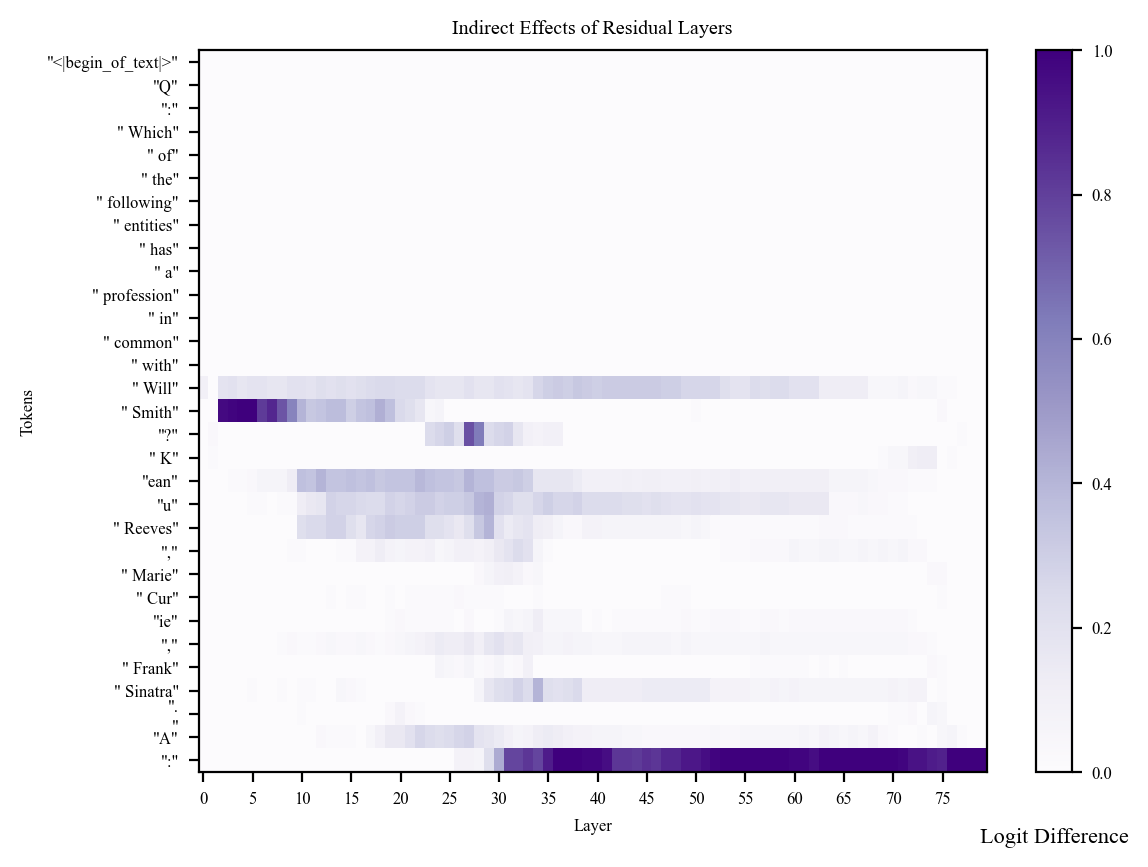

Data shape: (31, 80)
Number of tokens: 31


In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2D array: layers as rows, tokens as columns, then transpose
scores = np.array(patched_activations).T  # Transpose so tokens are rows, layers are columns
print(f"Scores shape after transpose: {scores.shape}")

# Decode tokens to actual text
corrupt_tokens = [model.tokenizer.decode([token_id]) for token_id in corrupt_input_ids]
clean_tokens = [model.tokenizer.decode([token_id]) for token_id in clean_input_ids]

# Create token labels
tokens = []
for idx, (corrupt_tok, clean_tok) in enumerate(zip(corrupt_tokens, clean_tokens)):
    tokens.append(f'"{clean_tok}"')

# We will truncate to the 0 to 1 range, but this is the full actual range.
print(f"Data range: min={scores.min():.4f}, max={scores.max():.4f}")

plt.rcdefaults()
with plt.rc_context(
    rc={
        "font.family": "Times New Roman",
        "font.size": 6,
    }
):
    # Set figure size
    fig, ax = plt.subplots(
        figsize=(
            6,
            len(tokens) * 0.08 + 1.8
        ),
        dpi=200
    )
    
    # Scale range
    scale_kwargs = {
        "vmin": 0,
        "vmax": 1
    }

    heatmap = ax.pcolor(
        scores,
        cmap="Purples",
        **scale_kwargs,
    )

    ax.invert_yaxis()
    
    # Y-axis: token labels (rows)
    ax.set_yticks([0.5 + i for i in range(scores.shape[0])])  # Number of tokens
    ax.set_yticklabels(tokens)
    
    # X-axis: layer labels (columns)
    num_layers = scores.shape[1]
    tick_indices = np.arange(0, num_layers, 5)
    ax.set_xticks(tick_indices + 0.5)  # Number of layers
    ax.set_xticklabels(tick_indices)

    title = f"Indirect Effects of Residual Layers"
    ax.set_title(title)

    ax.set_xlabel("Layer")
    ax.set_ylabel("Tokens")

    color_scale = plt.colorbar(heatmap)
    color_scale.ax.set_title(
        f"Logit Difference",
        y=-0.12,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

print(f"Data shape: {scores.shape}")
print(f"Number of tokens: {len(tokens)}")



Based on the above plot, we can make the following suppositions:

- The early activations at the Smith token suggests that the earlier layers rely heavily on the representation of "Will Smith" for making the correct prediction. Perhaps the model uses this time to understand who Will Smith is, what attributes he possesses, what his profession is.

- The activations in the early layers for the Keanu Reeves token suggest this is when the model is retriving information about Keanu Reeves to inform its prediction.

- The activations at the "?" token in the early-middle layers suggests the model is taking the whole previous sentence as a statement and considering it all at once.

- By layer 30, the model activates strongest at the last token position, suggesting that the relevant information for making the correct next token prediction has already been extracted by this point.

## Final Thoughts

Patching at the residual stream level is informative, but it is the most coarse-grained form of patching we can do.
For a more fine-grained analysis, we will want to observe the activations in the mlp and attention layers, which we will do in the next notebook.